In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path ='/content/drive/MyDrive/diabetes_dataset.csv'
df = pd.read_csv(file_path)
print(df)


     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [ ]:
print(df.head())
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


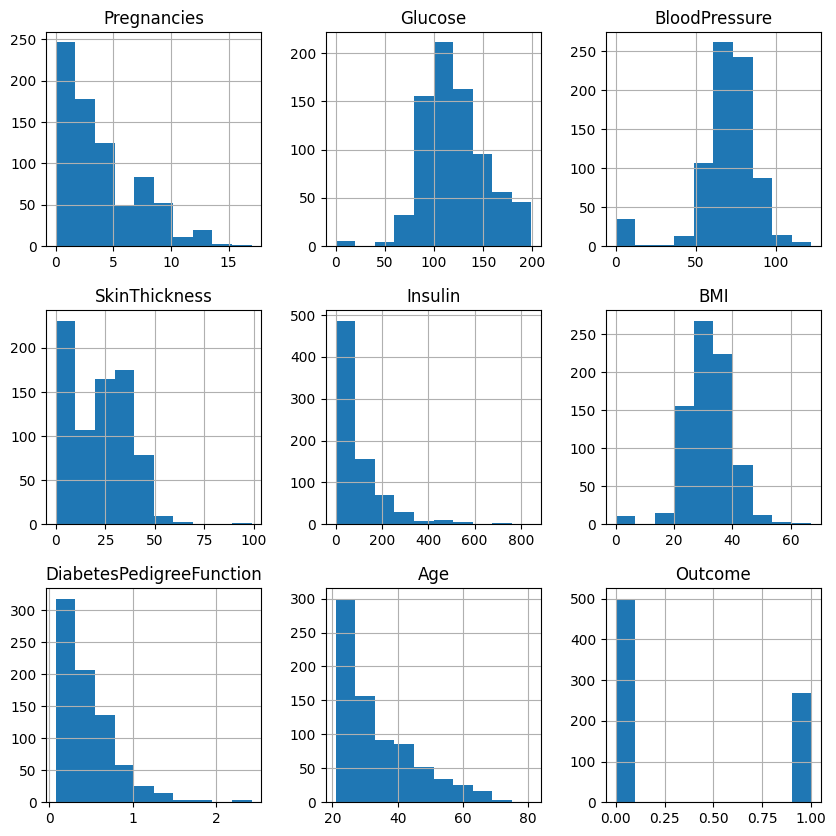

In [ ]:
df.hist(figsize=(10,10))
plt.show()

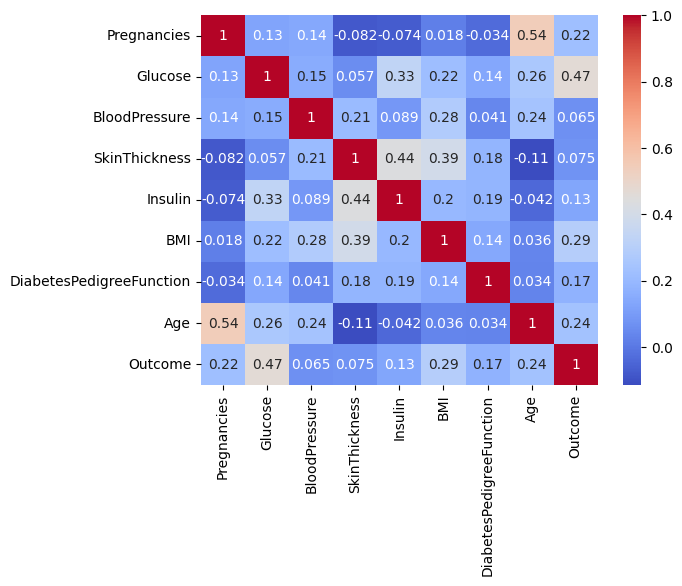

In [ ]:
corr_matrix =df.corr()
sns.heatmap(corr_matrix, annot=True, cmap ='coolwarm')
plt.show()

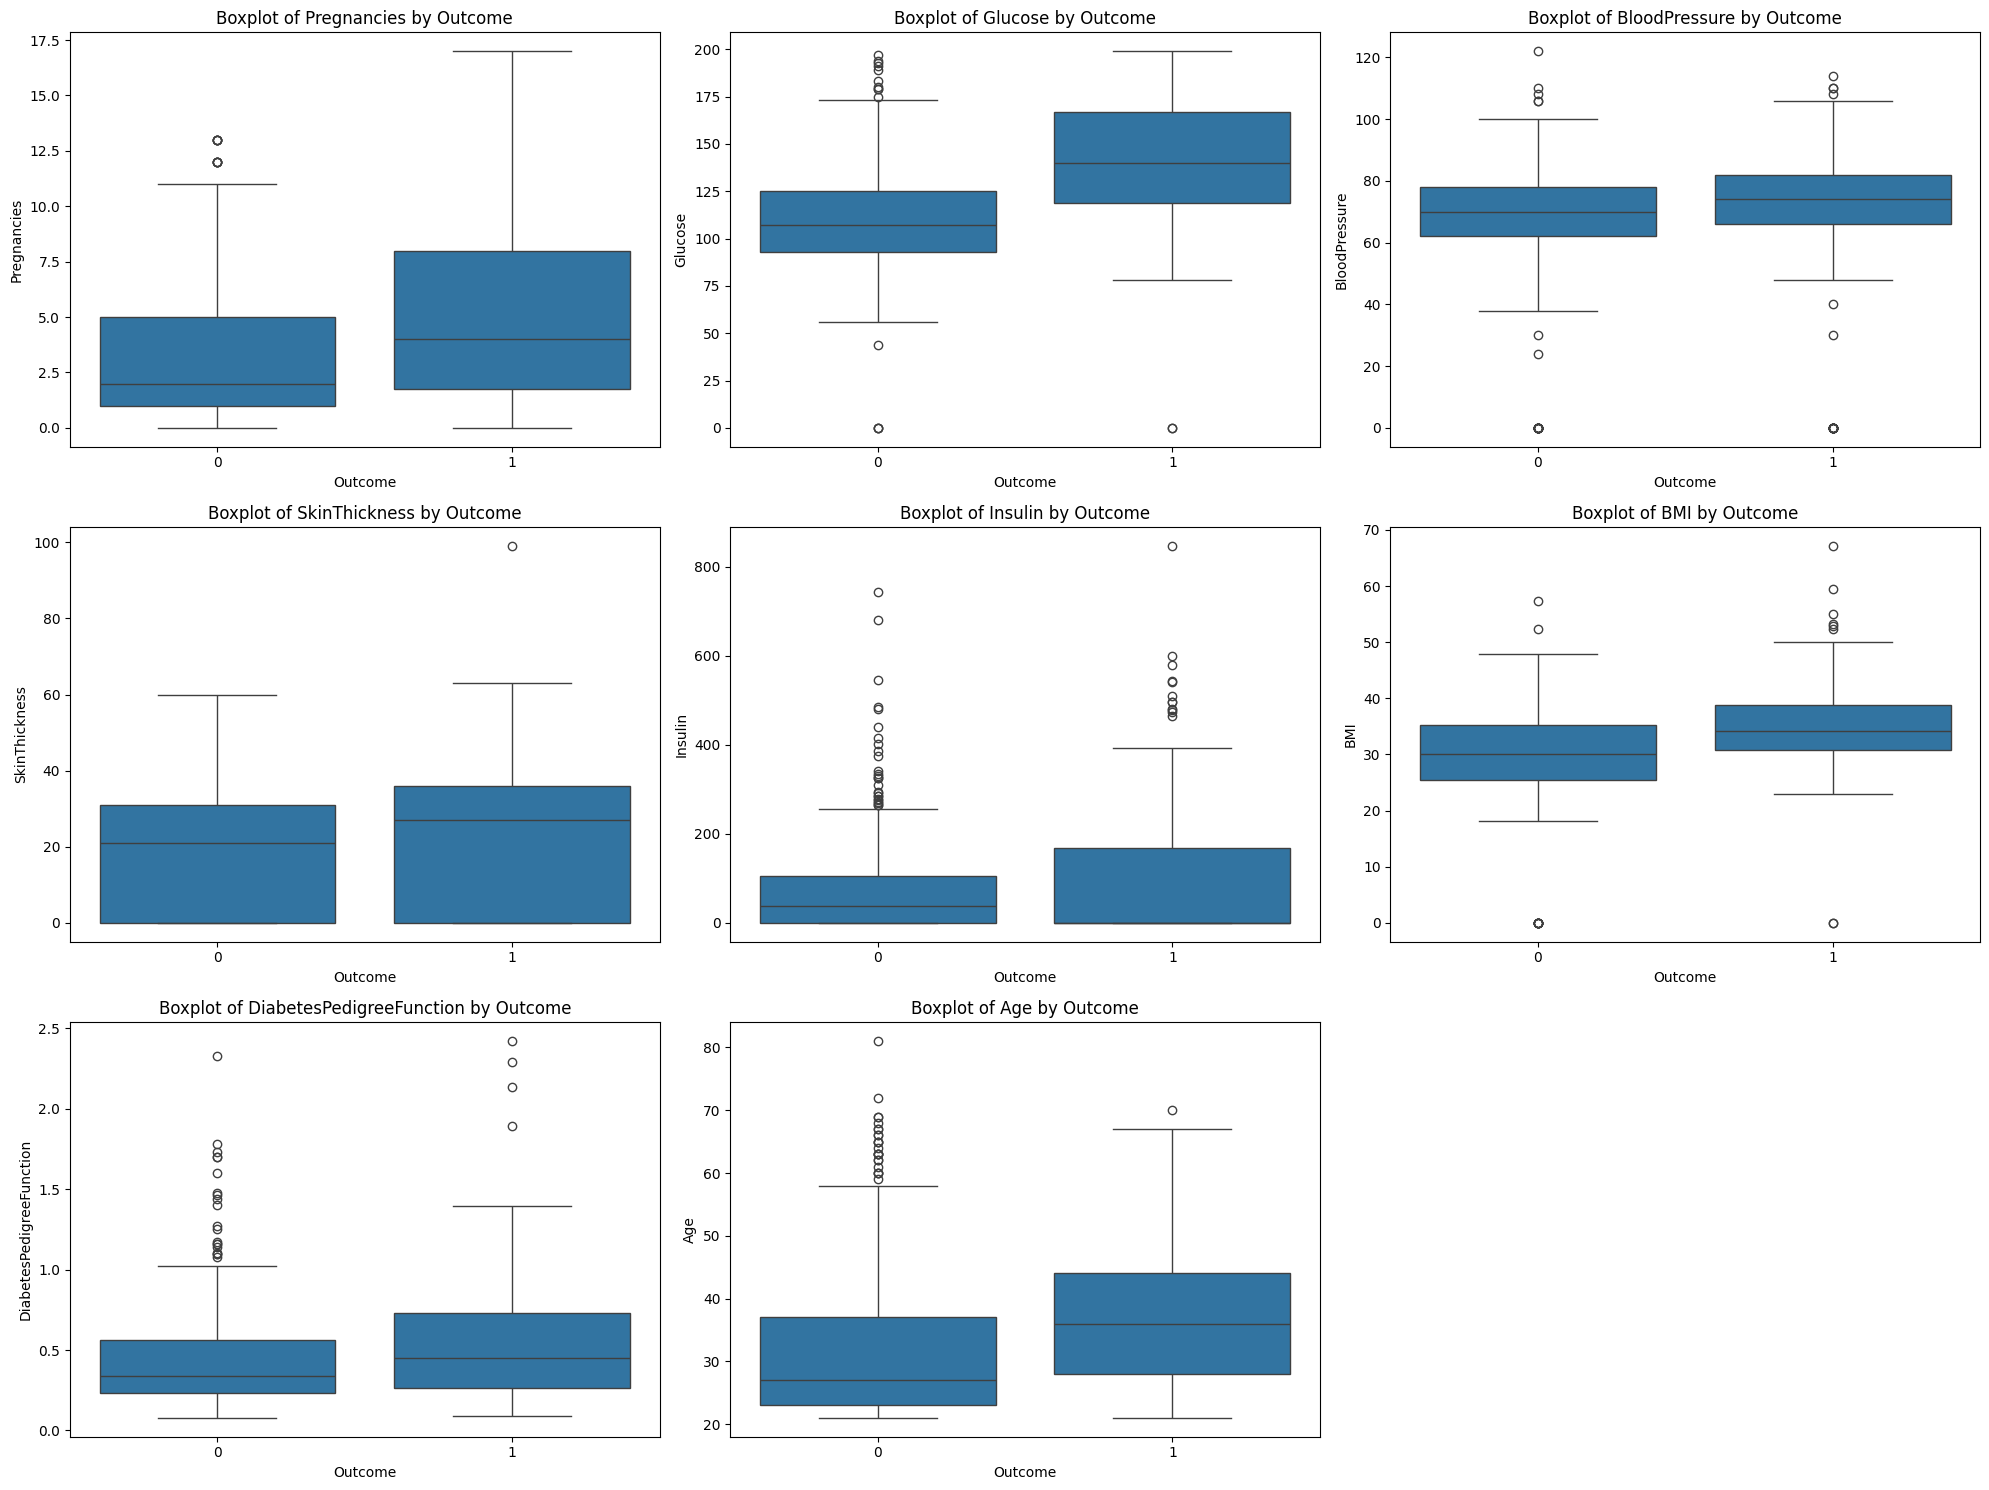

In [ ]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
            'BMI', 'DiabetesPedigreeFunction', 'Age']
plt.figure(figsize=(20, 15))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Outcome', y=feature, data=df)
    plt.title(f'Boxplot of {feature} by Outcome')


plt.tight_layout()
plt.show()

In [ ]:
x = df.drop('Outcome', axis=1)
y = df['Outcome']


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2,
                                                    random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)



In [ ]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
print("Logistic Regression Accuracy:")
accuracy_score(y_test, y_pred)

Logistic Regression Accuracy:


0.7857142857142857

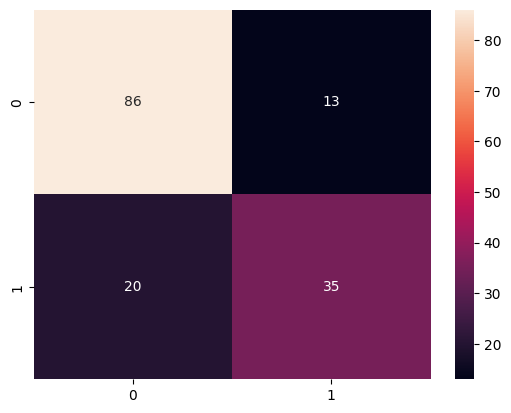

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

In [ ]:
def predict_outcome():
  features = []
  for col in x.columns:
    val = float(input(f"Enter {col}: "))
    features.append(val)

  features = np. array(features).reshape(1,-1)
  features = scaler.transform(features)

  prediction = lr.predict(features)
  if(prediction[0] ==1):
    print("DIABETIC")
  else:
    print("NOT DIABETIC")


In [ ]:
predict_outcome()

Enter Pregnancies: 2
Enter Glucose: 145
Enter BloodPressure: 42
Enter SkinThickness: 23
Enter Insulin: 94
Enter BMI: 43.1
Enter DiabetesPedigreeFunction: 0.627
Enter Age: 35
DIABETIC


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
